In [57]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sk
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import math

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Input, Dropout, LSTM, Dense, Layer, LayerNormalization, BatchNormalization, Conv1D, MaxPooling1D, Reshape, Add
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping

import yfinance as yf
import pandas_ta as ta

import warnings
warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option('display.max_columns', None)


In [58]:
def apply_ssa_trend(series, window = 15, lookback = 60):
    n_total = len(series)
    result = np.zeros(n_total)
    
    result[:lookback] = series[:lookback]
    
    for t in range(lookback, n_total):
        sub_series = series[t - lookback + 1 : t + 1]
        
        N = len(sub_series)
        L = window
        K = N - L + 1
        X = np.column_stack([sub_series[i:i+L] for i in range(K)])
        
        U, Sigma, VT = np.linalg.svd(X, full_matrices=False)
        
        X1 = Sigma[0] * np.outer(U[:, 0], VT[0, :])
        
        n = N - 1
        vals = [X1[i, n-i] for i in range(max(0, n-K+1), min(n+1, L))]
        result[t] = np.mean(vals)
        
    return result

def normalize_window(window):
    mean = window.mean(axis = 0)
    std = window.std(axis = 0) + 1e-8
    return (window - mean) / std

In [85]:
def get_dataset_columns(ticker, period="1y", window_size=60):
    df = yf.Tickers(ticker).history(period=period, progress=False)
    vix_data = yf.Tickers("^VIX").history(period=period, progress=False)

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.droplevel(1)
    if isinstance(vix_data.columns, pd.MultiIndex):
        vix_data.columns = vix_data.columns.droplevel(1)

    df = df.ffill().dropna()
    vix_data = vix_data.reindex(df.index).ffill()

    open_trend = apply_ssa_trend(df['Open'].values, window=int((window_size/4)))
    vix_trend  = apply_ssa_trend(vix_data['Open'].values, window=int((window_size/4)))

    min_len = min(len(df), len(open_trend), len(vix_trend))
    df = df.iloc[:min_len]

    ########################################################################

    # Features
    
    df['Open_Trend'] = open_trend[:min_len]
    df['Vix_Trend'] = vix_trend[:min_len]
    df['Trend_Diff'] = df['Open'] - df['Open_Trend']
    df['Vix_Trend_Diff'] = vix_data['Open'] - df['Vix_Trend']

    df['RSI'] = ta.rsi(df['Open'], length=14)

    macd = ta.macd(df['Open'])
    df = pd.concat([df, macd], axis=1)

    bbands = ta.bbands(df['Open'], length=20)
    df = pd.concat([df, bbands], axis=1)

    df['ATR'] = ta.atr(df['High'], df['Low'], df['Open'], length=14)

    df['Daily_Range'] = (df['High'] - df['Low']) / df['Open']

    df['VIX_Rel'] = vix_data['Open'] / vix_data['Open'].rolling(20).mean()

    ########################################################################

    # Target

    df['Target'] = (df['Open'].shift(-1) - df['Open']) / df['Open'] * 100
    # df['Target'] = np.log(df['Open'].shift(-1) / df['Open']) * 100
    # df['Target'] = df['Open'].shift(-1)

    ########################################################################

    df = df.iloc[:-1]

    df = df.drop(df.index[0])
    # df = df.drop(['High', 'Low', 'Volume', 'Close', 'Stock Splits', 'Dividends'], axis=1)
    
    df.columns.name = None
    exclude_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Target']
    feature_cols = [c for c in df.columns if c not in exclude_cols]
    target_col = ["Target"]

    return df, feature_cols, target_col

In [86]:
def get_full_dataset(tickers, period="1y", window_size=60, test_size=0.2):
    X_total, y_total = [], []
    
    for ticker in tickers:
        df, feature_cols, target_col = get_dataset_columns(ticker, period=period, window_size=window_size)
        data_x = df[feature_cols].values
        data_y = df[target_col].values
        
        for i in range(len(df) - window_size):
            window_x = data_x[i : i + window_size]
            window_y = data_y[i + window_size]

            window_x = normalize_window(window_x)

            X_total.append(window_x)
            y_total.append(window_y)

    X_data = np.array(X_total)
    y_data = np.array(y_total)

    nan_mask = np.isnan(X_data).any(axis=(1, 2))
    X_data = X_data[~nan_mask]
    y_data = y_data[~nan_mask] 

    print(f"NaN Deleted: {np.sum(nan_mask)}")
    
    test_first_index = int(len(X_data) * (1 - test_size))
    X_train, X_test = X_data[:test_first_index], X_data[test_first_index:]
    y_train, y_test = y_data[:test_first_index], y_data[test_first_index:]

    print("""
    X_train Shape : {}
    X_test Shape : {}
    y_train Shape : {}
    y_test Shape : {}
    """.format(X_train.shape, X_test.shape, y_train.shape, y_test.shape))
    
    return X_train, X_test, y_train, y_test

In [87]:
def get_data_for_prediction(ticker, period="120d", window_size=60):
    df, feature_cols, _ = get_dataset_columns(ticker, period=period, window=window_size)

    if len(df) < window_size:
        raise ValueError("Not enough rows")

    X = df[feature_cols].iloc[-window_size:].values

    if np.isnan(X).any():
        raise ValueError("NaN detected in prediction window")

    X = normalize_window(X)

    X = X.reshape(1, window_size, len(feature_cols))

    return X

## Training

In [88]:
tickers_5 = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA"]
tickers_20 = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA", 
    "TSM", "AVGO", "ASML",
    "JPM", "BAC", "V", "MA",
    "JNJ", "LLY", "UNH", "PG", "KO", "PEP"
]
tickers_50 = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "META", "TSLA", "NFLX", "ADBE", "CRM", "ORCL",
    "NVDA", "TSM", "AVGO", "ASML", "AMD", "INTC", "QCOM", "TXN", "MU", "AMAT",
    "JPM", "BAC", "V", "MA", "GS", "MS", "AXP", "PYPL", "WFC", "BLK",
    "JNJ", "LLY", "UNH", "PFE", "ABBV", "MRK", "TMO", "DHR", "AMGN", "ISRG",
    "PG", "KO", "PEP", "WMT", "COST", "NKE", "MCD", "HD", "DIS", "SBUX"
]

# Get Dataset For Training
window_size = 60
X_train, X_test, y_train, y_test = get_full_dataset(
    tickers_50,
    period = "3y",
    window_size = window_size, 
    test_size = 0.2
)
feature_num = X_train.shape[-1]

NaN Deleted: 1600

    X_train Shape : (26318, 60, 18)
    X_test Shape : (6580, 60, 18)
    y_train Shape : (26318, 1)
    y_test Shape : (6580, 1)
    


In [158]:
def get_CNN_LSTM_hybrid(window_size=60, feature_num=3):
    dropout_rate = 0.2
    
    input_layer = Input(shape=(window_size, feature_num), name="Input")
    
    x = Conv1D(filters=64, kernel_size=3, strides=1, padding='same', activation='relu', name="Conv1D_1")(input_layer)
    x = LayerNormalization(name="LayerNormalization_1")(x)
    x = Conv1D(filters=64, kernel_size=3, strides=1, padding='same', activation='relu', name="Conv1D_2")(x)
    x = LayerNormalization(name="LayerNormalization_2")(x)
    
    x = MaxPooling1D(pool_size=2, name="Max_Pooling")(x)
    
    x = LSTM(64, return_sequences=True, name="LSTM_1")(x)
    x = Dropout(dropout_rate, name="Dropout_1")(x)
    x = BatchNormalization(name="BatchNormalization_1")(x)
    
    x = LSTM(32, return_sequences=False, name="LSTM_2")(x)
    x = Dropout(dropout_rate, name="Dropout_2")(x)
    x = BatchNormalization(name="BatchNormalization_2")(x)
    
    x = Dense(16, activation="relu", name="FullyConnected_1")(x)
    output_layer = Dense(1, activation="linear", name="Output")(x)

    model = Model(inputs=input_layer, outputs=output_layer, name='SSA_CNN_LSTM_Hybrid')

    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, 
                  loss='mse', 
                  metrics=['mae', tf.keras.metrics.RootMeanSquaredError()])
    return model

CNN_LSTM_model = get_CNN_LSTM_hybrid(window_size, feature_num)
CNN_LSTM_model.summary()

Model: "SSA_CNN_LSTM_Hybrid"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 60, 18)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv1D_1 (Conv1D)               │ (None, 60, 64)         │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LayerNormalization_1            │ (None, 60, 64)         │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv1D_2 (Conv1D)               │ (None, 60, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LayerNormalization_2            │ (None, 60, 64)         │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Pooling (MaxPooling1D)      │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_1 (LSTM)                   │ (None, 30, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNormalization_1            │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNormalization_2            │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FullyConnected_1 (Dense)        │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,497 (244.13 KB)

 Trainable params: 62,305 (243.38 KB)

 Non-trainable params: 192 (768.00 B)

In [159]:
earlyStopping_callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.001,
    patience=5,
    verbose=0,
    mode="auto",
    baseline=None,
    restore_best_weights=True,
)

CNN_LSTM_model.fit(
    X_train, 
    y_train, 
    epochs = 50, 
    batch_size = 32,
    validation_data = (X_test, y_test),
    callbacks = [earlyStopping_callback]
)

Epoch 1/50
823/823 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - loss: 5.2640 - mae: 1.5304 - root_mean_squared_error: 2.2943 - val_loss: 2.3045 - val_mae: 1.0296 - val_root_mean_squared_error: 1.5181
Epoch 2/50
823/823 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - loss: 5.1619 - mae: 1.5088 - root_mean_squared_error: 2.2720 - val_loss: 2.2690 - val_mae: 1.0192 - val_root_mean_squared_error: 1.5063
Epoch 3/50
823/823 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - loss: 5.1461 - mae: 1.5068 - root_mean_squared_error: 2.2685 - val_loss: 2.2825 - val_mae: 1.0293 - val_root_mean_squared_error: 1.5108
Epoch 4/50
823/823 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - loss: 5.0969 - mae: 1.5034 - root_mean_squared_error: 2.2576 - val_loss: 2.2555 - val_mae: 1.0263 - val_root_mean_squared_error: 1.5018
Epoch 5/50
823/823 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - loss: 5.0623 - mae: 1.4985 - root_mean_squared_error: 2.2500 - val_loss: 2.2648 - val_mae: 1.0257 - val_root_mean_squared_error: 1.5049
Epoch 6/50
823/823 ━━━━━━━━━━━━━━━━━━━━ 

In [160]:
loss, mae, rmse = CNN_LSTM_model.evaluate(X_test, y_test)

print(f"loss: {loss}")
print(f"mae: {mae}")
print(f"rmse: {rmse}")

print("----------------")

206/206 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.2555 - mae: 1.0263 - root_mean_squared_error: 1.5018
loss: 2.2555441856384277
mae: 1.0262682437896729
rmse: 1.5018469095230103
----------------


206/206 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
                 0
count  6580.000000
mean      0.025750
std       0.241857
min      -0.820541
25%      -0.049166
50%       0.075419
75%       0.134654
max       4.510424
Test set class distribution:
Class 0: 3198 samples
Class 1: 240 samples
Class 2: 3142 samples

Prediction set class distribution:
Class 0: 2137 samples
Class 1: 1868 samples
Class 2: 2575 samples


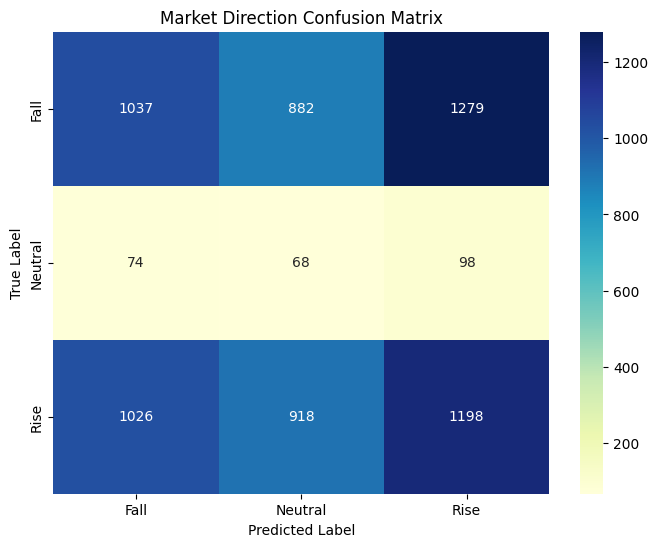


Classification Report:
              precision    recall  f1-score   support

        Fall       0.49      0.32      0.39      3198
     Neutral       0.04      0.28      0.06       240
        Rise       0.47      0.38      0.42      3142

    accuracy                           0.35      6580
   macro avg       0.33      0.33      0.29      6580
weighted avg       0.46      0.35      0.39      6580



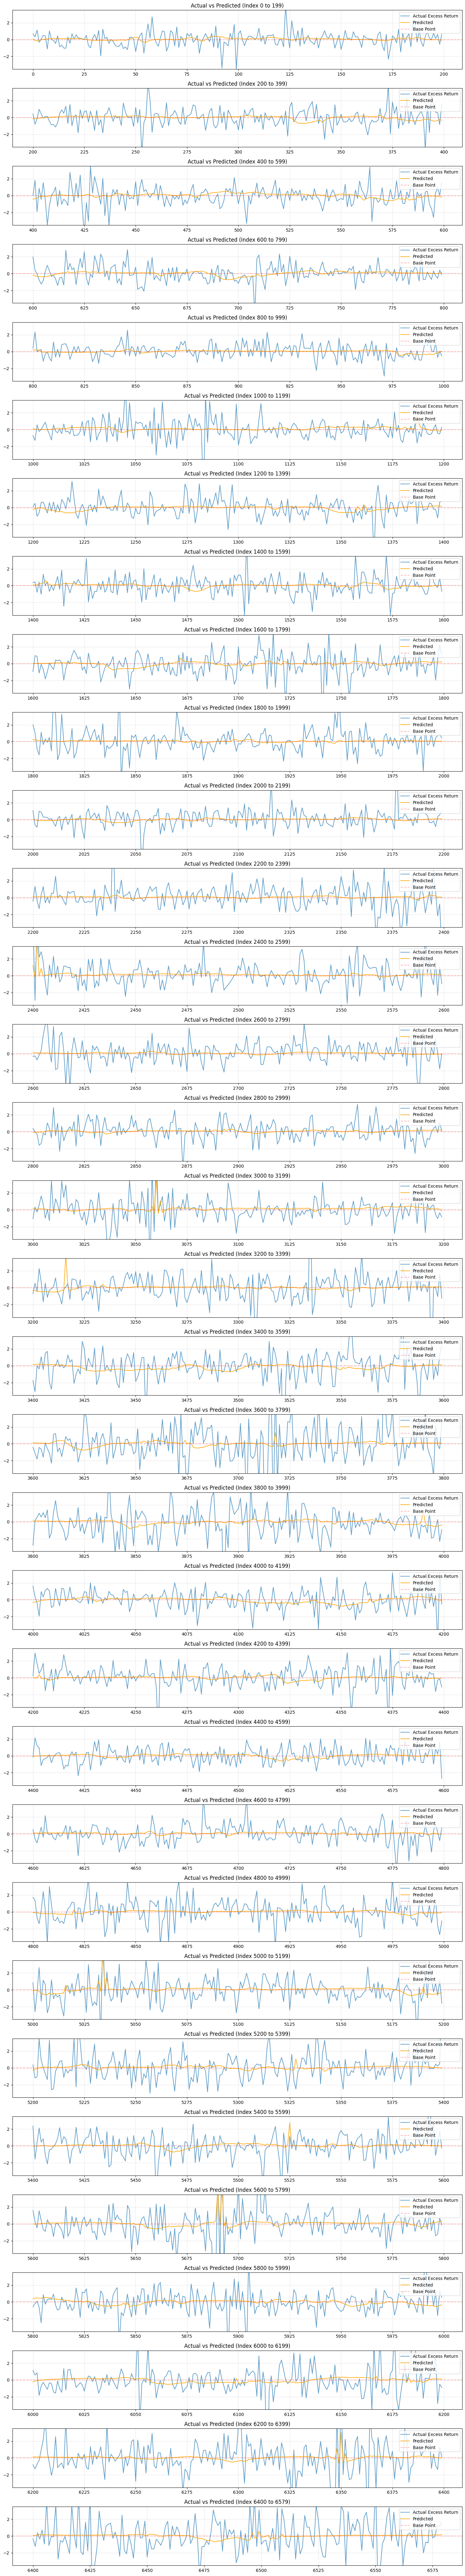

In [ ]:
def make_3class_label(y, threshold=0.05):
    labels = np.zeros_like(y, dtype=int)

    labels[y > threshold] = 2
    labels[(y > 0) & (y <= threshold)] = 1 
    labels[y <= 0] = 0
    
    return labels

predictions = CNN_LSTM_model.predict(X_test)

print(pd.DataFrame(predictions).describe())

# base_point = pd.DataFrame(predictions).mean().item()
base_point = 0
class_names = ['Fall', 'Neutral', 'Rise']
threshold = 0.1

y_test_class = make_3class_label(y_test, threshold)
predictions_class = make_3class_label(predictions, threshold)

unique, counts = np.unique(y_test_class, return_counts=True)
print("Test set class distribution:")
for u, c in zip(unique, counts):
    print(f"Class {u}: {c} samples")

unique, counts = np.unique(predictions_class, return_counts=True)
print("\nPrediction set class distribution:")
for u, c in zip(unique, counts):
    print(f"Class {u}: {c} samples")

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_class, predictions_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Market Direction Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test_class, predictions_class, target_names=class_names))

y_test_flat = y_test.flatten()
preds_flat = predictions.flatten()

comparison_df = pd.DataFrame({
    'Actual': y_test_flat,
    'Predicted': preds_flat
})

chunk_size = 200
y_min_limit = -3.5 
y_max_limit = 3.5 

total_len = len(comparison_df)
num_plots = int(np.ceil(total_len / chunk_size))

fig, axes = plt.subplots(num_plots, 1, figsize=(15, 2.5 * num_plots), sharex=False)

if num_plots == 1:
    axes = [axes]

for i in range(num_plots):
    start = i * chunk_size
    end = min((i + 1) * chunk_size, total_len)
    
    subset = comparison_df.iloc[start:end]
    
    axes[i].plot(subset.index, subset['Actual'], label='Actual Excess Return', alpha=0.7)
    axes[i].plot(subset.index, subset['Predicted'], label='Predicted', alpha=0.9, color='orange')
    
    axes[i].set_ylim(y_min_limit, y_max_limit) 
    
    axes[i].axhline(base_point, label='Base Point', color='red', linestyle='--', alpha=0.3)
    axes[i].set_title(f'Actual vs Predicted (Index {start} to {end-1})')
    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Backtesting

In [ ]:
def get_backtest_data(ticker, period="2y", window_size=60):
    df, feature_cols, target_col = get_dataset_columns(ticker, period=period, window_size=window_size)

    data_x = df[feature_cols].values
    data_y = df[target_col].values
    data_open_close = df[["Open", "Close"]].values

    X_list = []
    y_real = []
    dates_list = []
    actual_opens_list = []

    for i in range(len(df) - window_size):
        window_x = data_x[i : i + window_size]
        window_y = data_y[i + window_size]

        if np.isnan(window_x).any() or np.isnan(window_y).any():
            continue
        
        window_x = normalize_window(window_x)
        current_open = data_open_close[i + window_size]
        
        X_list.append(window_x)
        y_real.append(window_y)
        dates_list.append(df.index[i + window_size])
        actual_opens_list.append(current_open)

    return np.array(X_list), np.array(y_real), dates_list, feature_cols, np.array(actual_opens_list)

def backtest(model, ticker, period="1y", window_size=60, initial_capital=10000):
    X_bt, y_bt, bt_dates, feature_cols, data_open = get_backtest_data(ticker, period=period, window_size=window_size)
    predictions = model.predict(X_bt, verbose=0).flatten()

    previous_signal = "INIT"
    previous_correct_signal = "INIT"
    
    cash = initial_capital
    cash_when_not_traded = initial_capital
    cash_fixed = 0
    shares = 0
    threshold = 0.1
    portfolio_history = []

    buy_count = 0
    buy_correct_count = 0
    actual_buy_count = 0
    sell_count = 0
    sell_correct_count = 0
    actual_sell_count = 0
    hold_count = 0
    hold_correct_count = 0
    actual_hold_count = 0

    correct_pred_count = 0
    wrong_pred_count = 0 

    current_open_price = data_open[0][0]
    shares_when_not_traded = cash_when_not_traded // current_open_price
    cash_when_not_traded -= shares_when_not_traded * current_open_price
    
    for i in range(len(bt_dates)):
        current_open_price = data_open[i][0]
        y_act = y_bt[i][0]
        cash_when_not_traded = shares_when_not_traded * current_open_price

        if y_act >= threshold:
            correct_signal = "BUY"
            actual_buy_count += 1
        elif y_act <= -0.5 * threshold:
            correct_signal = "SELL"
            actual_sell_count += 1
        else:
            correct_signal ="HOLD"
            actual_hold_count += 1

        correct = False

        if predictions[i] >= threshold:
            signal = "BUY"
            buy_count += 1
            if correct_signal == "BUY":
                correct = True
        elif predictions[i] <= -1 * threshold:
            signal = "SELL"
            sell_count += 1
            if correct_signal == "SELL":
                correct = True
        else:
            signal ="HOLD"
            hold_count += 1
            if correct_signal == "HOLD":
                correct = True

        action = "HOLD" if signal == previous_signal else signal
        previous_signal = previous_signal if signal == "HOLD" else signal

        if signal=="BUY" and cash > current_open_price:
            share_num = cash // current_open_price
            cash -= share_num * current_open_price
            shares += share_num

        elif signal=="SELL" and shares > 0:
            cash += shares * current_open_price
            shares = 0

        if cash > initial_capital:
            rev = cash - initial_capital
            cash -= rev
            cash_fixed += rev

        total_value = cash_fixed + cash + (shares * current_open_price)

        if correct:
            correct_pred_count += 1

            if signal == "BUY":
                buy_correct_count += 1
            elif signal == "SELL":
                sell_correct_count += 1
            elif signal == "HOLD":
                hold_correct_count += 1
        else :
            wrong_pred_count += 1

        portfolio_history.append({
            'Date': bt_dates[i],
            'Signal': signal,
            'Co. Signal': correct_signal,
            'Correct': correct,

            'Open': current_open_price,
            'Actual': y_act,
            'Pred': predictions[i],
            'Action': action,
            'Shares': shares,
            'Cash': cash,
            'Cash Fixed': cash_fixed,
            'Total_Wallet': total_value,
            'Return (%)': ((total_value - initial_capital) / initial_capital) * 100,
            'No Trading : Cash': cash_when_not_traded,
            'No Trading : Return': ((cash_when_not_traded - initial_capital) / initial_capital) * 100,

            'SOLD when BUY':signal=="SELL" and correct_signal=="BUY",
            'BOUGHT when SELL': signal=="BUY" and correct_signal=="SELL",

            'Pred. Buys': buy_count,
            'Act. Buys': actual_buy_count,

            'Pred. Sells': sell_count,
            'Act. Sells': actual_sell_count,

            'Pred. Holds': hold_count,
            'Act. Holds': actual_hold_count,

            'Co. Buys': buy_correct_count,
            'Co. Sells': sell_correct_count,
            'Co. Holds': hold_correct_count,
            
            'Co. Dec': correct_pred_count,
            'Wr. Dec': wrong_pred_count,
        })
    result_df = pd.DataFrame(portfolio_history)
    return result_df

def plotBacktestResult(df, print_detail=False):
    row_num = 5 if print_detail else 2
    figsize = (10, 12) if print_detail else (10, 6)
    fig, axs = plt.subplots(row_num, 1, figsize=figsize, sharex=True)

    other_cols = ["Shares", "Cash", "Cash Fixed"]
    other_colors = ["#DC143C", "#9370DB", "#4169E1"]
    
    buy_signals = df[df['Action'] == 'BUY']
    sell_signals = df[df['Action'] == 'SELL']

    axs[0].plot(df.index, df['Open'], label='Open', color='#4169E1', alpha=0.7)
    axs[0].scatter(buy_signals.index, buy_signals['Open'], 
                    marker='o', color='green', s=20, label='BOUGHT', edgecolor='black', zorder=5)
    axs[0].scatter(sell_signals.index, sell_signals['Open'], 
                    marker='o', color='red', s=20, label='SOLD', edgecolor='black', zorder=5)
    axs[0].set_ylabel('Price (Open)')
    axs[0].set_title('Open')
    axs[0].legend(loc='upper left')

    axs[1].plot(df.index, df['Return (%)'], label='Return using the model', color='#FFA500', alpha=0.7)
    axs[1].plot(df.index, df['No Trading : Return'], label='Return if not traded', color='#2E8B57', alpha=0.7)
    axs[1].axhline(y=0, color='gray', linestyle='--', linewidth=1.5)
    axs[1].set_ylabel('Return %')
    axs[1].set_title('Return Using This Model vs Not Trading')
    axs[1].legend(loc='upper left')

    if (print_detail):
        for i, col_name in enumerate(other_cols):
            ax_idx = i + 2
            axs[ax_idx].plot(df.index, df[col_name], label=col_name, color=other_colors[i])
            axs[ax_idx].set_title(col_name)
            axs[ax_idx].legend(loc='upper left')

    for ax in axs:
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [361]:
additional_large_caps = [
    "V", "MA", "HSBC", "RY", "TD", "C", "BNP.PA", "SAN", "CB",
    "NVO", "AZN", "SNY", "GSK", "SYK", "ZTS", "BDX", "ELV", "CI", "HCA",
    "XOM", "CVX", "LIN", "SHEL", "TTE", "BP", "SLB", "COP", "EOG", "MPC",
    "CAT", "GE", "LMT", "RTX", "HON", "BA", "UPS", "DE", "MMM", "GEV",
    "TM", "LVMUY", "NSRGY", "UL", "BABA", "TGT", "TJX", "MDLZ", "EL",
    "SAP", "NOW", "PLTR", "PANW", "SNPS", "CDNS", "UBER", "ABNB", "T", "VZ",
    "LRCX", "KLAC", "TEL", "MCHP", "ON", "STLA", "ANET", "EQIX", "PLD", "AMT"
]

Result for : EL


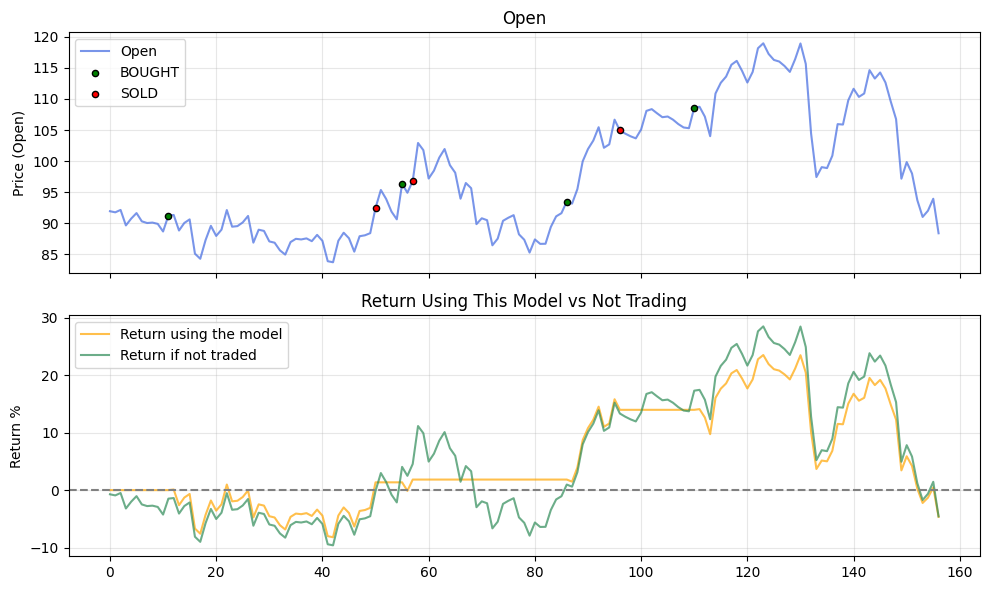

Co.: Correct | Wr.: Wrong | Dec: Decision
Using the model : -4.653%,
Not using the model : -4.56%


,Date,Signal,Co. Signal,Correct,Open,Actual,Pred,Action,Shares,Cash,Cash Fixed,Total_Wallet,Return (%),No Trading : Cash,No Trading : Return,SOLD when BUY,BOUGHT when SELL,Pred. Buys,Act. Buys,Pred. Sells,Act. Sells,Pred. Holds,Act. Holds,Co. Buys,Co. Sells,Co. Holds,Co. Dec,Wr. Dec
0,2025-07-29,HOLD,SELL,False,91.9214,-0.1937,0.0880,HOLD,0.0,10000.0000,0.0000,10000.0000,0.0000,9927.5073,-0.7249,False,False,0,0,0,1,1,0,0,0,0,0,1
1,2025-07-30,HOLD,BUY,False,91.7433,0.4206,0.0848,HOLD,0.0,10000.0000,0.0000,10000.0000,0.0000,9908.2741,-0.9173,False,False,0,1,0,1,2,0,0,0,0,0,2
2,2025-07-31,HOLD,SELL,False,92.1291,-2.7062,0.0807,HOLD,0.0,10000.0000,0.0000,10000.0000,0.0000,9949.9465,-0.5005,False,False,0,1,0,2,3,0,0,0,0,0,3
3,2025-08-01,HOLD,BUY,False,89.6359,1.2252,0.0776,HOLD,0.0,10000.0000,0.0000,10000.0000,0.0000,9680.6813,-3.1932,False,False,0,2,0,2,4,0,0,0,0,0,4
4,2025-08-04,HOLD,BUY,False,90.7341,0.9814,0.0798,HOLD,0.0,10000.0000,0.0000,10000.0000,0.0000,9799.2860,-2.0071,False,False,0,3,0,2,5,0,0,0,0,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,2026-03-06,BUY,SELL,False,93.7000,-2.8815,0.1667,HOLD,92.0,7.9514,1396.6634,10025.0146,0.2501,10119.5997,1.1960,False,True,61,75,6,76,86,2,30,4,2,36,117
153,2026-03-09,HOLD,BUY,False,91.0000,1.0989,0.0598,HOLD,92.0,7.9514,1396.6634,9776.6148,-2.2339,9828.0000,-1.7200,False,False,61,76,6,76,87,2,30,4,2,36,118
154,2026-03-10,HOLD,BUY,False,92.0000,2.0978,0.0513,HOLD,92.0,7.9514,1396.6634,9868.6148,-1.3139,9936.0000,-0.6400,False,False,61,77,6,76,88,2,30,4,2,36,119
155,2026-03-11,HOLD,SELL,False,93.9300,-5.9193,-0.0166,HOLD,92.0,7.9514,1396.6634,10046.1749,0.4617,10144.4400,1.4444,False,False,61,77,6,77,89,2,30,4,2,36,120


In [387]:
company = additional_large_caps[47]
backtest_result = backtest(CNN_LSTM_model, company)
print(f"Result for : {company}")
plotBacktestResult(backtest_result)

print("Co.: Correct | Wr.: Wrong | Dec: Decision")
print(f"Using the model : {round(backtest_result['Return (%)'].iloc[-1], 3)}%,\nNot using the model : {round(backtest_result['No Trading : Return'].iloc[-1], 3)}%")
round(backtest_result, 4)


In [365]:
correct_count = 0
for cap in additional_large_caps:
    backtest_result = backtest(CNN_LSTM_model, cap)
    model_return  = backtest_result['Return (%)'].iloc[-1]
    simple_return = backtest_result['No Trading : Return'].iloc[-1]
    if model_return > simple_return:
        correct_count += 1

    print(f"For {cap} :\n - Return : {round(model_return, 2)}\n - Return w/o model : {round(simple_return, 2)}")

print(f"Performed Better With Model: {correct_count}/{len(additional_large_caps)}")

For V :
 - Return : -13.5
 - Return w/o model : -11.68
For MA :
 - Return : -1.37
 - Return w/o model : -12.12
For HSBC :
 - Return : 24.21
 - Return w/o model : 35.1
For RY :
 - Return : 8.71
 - Return w/o model : 24.88
For TD :
 - Return : 31.43
 - Return w/o model : 28.31
For C :
 - Return : 0.26
 - Return w/o model : 14.91
For BNP.PA :
 - Return : 4.11
 - Return w/o model : 17.12
For SAN :
 - Return : 10.02
 - Return w/o model : 29.03
For CB :
 - Return : 17.77
 - Return w/o model : 16.41
For NVO :
 - Return : -55.71
 - Return w/o model : -44.35
For AZN :
 - Return : 37.74
 - Return w/o model : 37.7
For SNY :
 - Return : -8.81
 - Return w/o model : -10.78
For GSK :
 - Return : 50.86
 - Return w/o model : 51.04
For SYK :
 - Return : -9.31
 - Return w/o model : -8.85
For ZTS :
 - Return : -11.1
 - Return w/o model : -19.51
For BDX :
 - Return : 2.95
 - Return w/o model : 15.13
For ELV :
 - Return : -1.08
 - Return w/o model : 0.53
For CI :
 - Return : -1.69
 - Return w/o model : -8.2

In [323]:
def save_model_weights(model, file_name, folder_name):
    os.makedirs(folder_name, exist_ok=True)

    words = file_name.split(".")

    model_name = words[0]

    existing_files = [f for f in os.listdir(folder_name) if f.startswith(model_name)]
    next_number = len(existing_files) + 1
    words[0] = f"{model_name}_{next_number}"

    file_name = ".".join(words)
    save_path = os.path.join(folder_name, file_name)

    model.save_weights(save_path)
    print(f"model saved to: {save_path}")

In [166]:
save_model_weights(CNN_LSTM_model, "CNN_LSTM_18_features.weights.h5", "models")

model saved to: models/CNN_LSTM_18_features_4.weights.h5
